# MC-simulering v2: Urval × Viktning × Portföljstorlek

Tre diskreta dimensioner varieras:
- **Urval**: `random`, `skew_high`, `momentum`
- **Viktning**: `equal`, `cap`, `risk_parity` (inverterad volatilitet)
- **Portföljstorlek**: 10, 50, 100 aktier

Portföljerna rebalanseras årsvis med max 30 % omsättning per period.


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product
from functools import lru_cache


In [23]:
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
try:
    plt.style.use('kvartil.mplstyle')
except Exception:
    pass


## 1. Ladda data


In [24]:
DATAFOLDER = r'analysdata'

AVKASTNINGAR = pd.read_pickle(DATAFOLDER + r'\avkastningar.pkl')
VIKTER       = pd.read_pickle(DATAFOLDER + r'\vikter.pkl')

UNIVERSE = VIKTER.columns.intersection(AVKASTNINGAR.columns)
AVKASTNINGAR = AVKASTNINGAR[UNIVERSE]
VIKTER       = VIKTER[UNIVERSE]

print(f'Universum : {len(UNIVERSE)} aktier')
print(f'Period    : {AVKASTNINGAR.index[0].date()} -> {AVKASTNINGAR.index[-1].date()}')
print(f'Dagar     : {len(AVKASTNINGAR)}')


Universum : 1253 aktier
Period    : 2005-03-24 -> 2025-03-21
Dagar     : 5090


## 2. Hjälpfunktioner


In [25]:
def get_kfs(rets, benchrets, periods_yr=12, monthly_vol=False):
    rets_m = rets
    benchrets_m = (
        (1 + benchrets)
        .cumprod()
        .resample('ME')
        .last()
        .pct_change()
        .dropna()
        .reindex(rets_m.index)
    )
    if len(rets) > len(rets_m) * 12:
        yrs = (rets.index[-1] - rets.index[0]) / np.timedelta64(365, 'D')
    else:
        yrs = len(rets_m) / 12
    dd = 1 - (1 + rets).cumprod() / (1 + rets).cumprod().expanding().max()
    yr = np.power((1 + rets).cumprod().iloc[-1], 1 / yrs) - 1
    if monthly_vol:
        yv = rets_m.std() * np.sqrt(12)
    else:
        yv = rets.std() * np.sqrt(periods_yr)
    max_dd          = dd.max()
    mean_dd         = dd.mean()
    ir              = yr / yv
    beta            = rets_m.corrwith(benchrets_m) * rets_m.std() / benchrets_m.std()
    downside_capture = rets_m[benchrets_m < 0].mean() / benchrets_m[benchrets_m < 0].mean()
    upside_capture   = rets_m[benchrets_m > 0].mean() / benchrets_m[benchrets_m > 0].mean()
    share_up_month  = (rets_m > 0).mean()
    avg_down_month  = rets_m[rets_m < 0].mean()
    avg_up_month    = rets_m[rets_m > 0].mean()
    rets_0          = rets.sub(rets.mean())
    upside_vol      = rets_0[rets_0 > 0].std() * np.sqrt(periods_yr)
    downside_vol    = rets_0[rets_0 < 0].std() * np.sqrt(periods_yr)
    batting_average = (rets_m.sub(benchrets_m, axis=0) >= 0.000001).mean()
    var95           = rets_m.quantile(0.05)
    var99           = rets_m.quantile(0.01)
    cvar            = rets_m[rets_m < var95].mean()
    skew            = rets_m.skew()
    kurtosis        = rets_m.kurtosis()
    sortino_ratio   = yr / downside_vol
    calmar_ratio    = yr / abs(max_dd)

    if type(yr) == pd.Series:
        return pd.concat(
            {
                'Return': yr, 'Vol': yv, 'Max DrawDown': max_dd,
                'Information Ratio': ir, 'Beta': beta,
                'Downside Capture': downside_capture, 'Upside capture': upside_capture,
                'Share up month': share_up_month, 'Avg. down-month': avg_down_month,
                'Avg. up-month': avg_up_month, 'Downside vol.': downside_vol,
                'Upside vol.': upside_vol, 'Batting average': batting_average,
                'VaR 95%': var95, 'VaR 99%': var99, 'Conditional VaR (5%)': cvar,
                'Skew': skew, 'Kurtosis': kurtosis,
                'Sortinokvot': sortino_ratio, 'Calmarkvot': calmar_ratio,
            },
            axis=1,
        )
    else:
        return pd.Series(
            {
                'Return': yr, 'Vol': yv, 'Max DrawDown': max_dd,
                'Information Ratio': ir, 'Beta': beta,
                'Downside Capture': downside_capture, 'Upside capture': upside_capture,
                'Share up month': share_up_month, 'Avg. down-month': avg_down_month,
                'Avg. up-month': avg_up_month, 'Downside vol.': downside_vol,
                'Upside vol.': upside_vol, 'Batting average': batting_average,
                'VaR 95%': var95, 'VaR 99%': var99, 'Conditional VaR (5%)': cvar,
                'Skew': skew, 'Kurtosis': kurtosis,
                'Sortinokvot': sortino_ratio, 'Calmarkvot': calmar_ratio,
            }
        )


In [26]:
def compute_signals(date, lookback_days=252):
    """Skevhet, momentum och volatilitet per aktie (lookback_days bakåt från date)."""
    window = AVKASTNINGAR.loc[:date].iloc[-lookback_days:]
    active = window.columns[window.count() >= lookback_days * 0.8]
    w = window[active]
    signals = pd.DataFrame({
        'skewness': w.skew(),
        'momentum': (1 + w).prod() - 1,
        'volatility': w.std() * np.sqrt(252),
    })
    return signals.dropna()


def get_selection_probs(signals, selection, top_pct=None):
    """
    Samplingsannolikheter baserade på urvalsstrategi.

    top_pct=None  → rank-proportionella sannolikheter (orig. beteende)
    top_pct=0.3   → uniform slumpning inom topp top_pct% av universumet;
                    aktier utanför toppen får sannolikhet 0.
    """
    _signal_col = {'skew_high': 'skewness', 'momentum': 'momentum'}

    if selection == 'random':
        n = len(signals)
        return pd.Series(1.0 / n, index=signals.index)

    if selection not in _signal_col:
        raise ValueError(f'Okänd urvalsmetod: {selection}')

    col = _signal_col[selection]

    if top_pct is not None:
        # Begränsa universumet till topp top_pct% – uniform sannolikhet inom toppen
        n_top = max(1, int(np.ceil(len(signals) * top_pct)))
        top_idx = signals[col].nlargest(n_top).index
        probs = pd.Series(0.0, index=signals.index)
        probs[top_idx] = 1.0 / n_top
    else:
        # Rank-proportionella sannolikheter: högre rank → högre sannolikhet
        ranks = signals[col].rank()
        probs = ranks / ranks.sum()

    return probs / probs.sum()


def get_weights_v2(tickers, date, weighting):
    """Portföljvikter: equal | cap | risk_parity (inverterad volatilitet)."""
    tickers = list(tickers)
    n = len(tickers)

    if weighting == 'equal':
        return pd.Series(1.0 / n, index=tickers)

    elif weighting == 'cap':
        idx = VIKTER.index.get_indexer([date], method='nearest')[0]
        w = VIKTER.iloc[idx][tickers].fillna(0).clip(lower=0)
        s = w.sum()
        return w / s if s > 0 else pd.Series(1.0 / n, index=tickers)

    elif weighting == 'risk_parity':
        # w_i = (1/σ_i) / Σ(1/σ_j)
        window = AVKASTNINGAR.loc[:date].iloc[-252:]
        vols = window[tickers].std()
        inv_vol = (1.0 / vols).replace([np.inf, -np.inf], np.nan).fillna(0)
        s = inv_vol.sum()
        return inv_vol / s if s > 0 else pd.Series(1.0 / n, index=tickers)

    else:
        raise ValueError(f'Okänd viktning: {weighting}')


In [27]:
def draw_initial_holdings(date, selection, pf_size, rng, top_pct=None):
    """Drar startportfölj vid första rebalanseringsdatum."""
    signals = compute_signals(date)
    if len(signals) < pf_size:
        raise ValueError(
            f'För få aktiva aktier ({len(signals)}) för pf_size={pf_size} vid {date.date()}'
        )
    probs = get_selection_probs(signals, selection, top_pct=top_pct).values
    chosen = rng.choice(signals.index, size=pf_size, replace=False, p=probs)
    return list(chosen)


def rebalance_holdings(date, prev_holdings, selection, pf_size, rng,
                        max_turnover=0.3, top_pct=None):
    """
    Uppdaterar innehav med begränsad omsättning.
    Vid top_pct-läge prioriteras aktier utanför toppen bort vid byte.
    """
    signals = compute_signals(date)
    if len(signals) < pf_size:
        return prev_holdings

    probs = get_selection_probs(signals, selection, top_pct=top_pct)

    # Aktier som fortfarande har tillräcklig data
    still_active = [t for t in prev_holdings if t in signals.index]

    # Antal att byta: minst det som avlistats, annars max_turnover
    n_forced = pf_size - len(still_active)
    n_swap   = max(int(np.floor(pf_size * max_turnover)), n_forced)
    n_keep   = pf_size - n_swap

    # Behåll de med högst sannolikhet (vid top_pct: aktier utanför toppen
    # får prob=0 och sorteras sist → byts ut först)
    if still_active:
        active_probs = probs.reindex(still_active, fill_value=0).sort_values(ascending=False)
        keep = list(active_probs.iloc[:n_keep].index)
    else:
        keep = []

    # Dra nya aktier bland kandidater (ej redan kvar)
    candidates = signals.index.difference(keep)
    cand_probs = probs.reindex(candidates, fill_value=0)
    s = cand_probs.sum()
    cand_probs = cand_probs / s if s > 0 else pd.Series(1.0 / len(candidates), index=candidates)

    n_new = min(pf_size - len(keep), len(candidates))
    new_picks = rng.choice(candidates, size=n_new, replace=False, p=cand_probs.values)

    return keep + list(new_picks)


def simulate_one_portfolio(selection, weighting, pf_size, seed, rebal_dates,
                            max_turnover=0.3, top_pct=None):
    """Simulerar en portfölj med periodisk ombalansering. Returnerar dagliga avkastningar."""
    rng = np.random.default_rng(seed)

    holdings = draw_initial_holdings(rebal_dates[0], selection, pf_size, rng, top_pct=top_pct)
    weights  = get_weights_v2(holdings, rebal_dates[0], weighting)

    all_returns = []

    for i in range(len(rebal_dates) - 1):
        t0 = rebal_dates[i]
        t1 = rebal_dates[i + 1]

        period_rets = AVKASTNINGAR.loc[t0:t1, holdings].fillna(0)
        w_aligned   = weights.reindex(period_rets.columns, fill_value=0)
        pf_rets     = period_rets.mul(w_aligned).sum(axis=1)
        all_returns.append(pf_rets.iloc[1:])  # undvik dubblerat startdatum

        if i < len(rebal_dates) - 2:
            holdings = rebalance_holdings(
                t1, holdings, selection, pf_size, rng,
                max_turnover=max_turnover, top_pct=top_pct
            )
            weights = get_weights_v2(holdings, t1, weighting)

    combined = pd.concat(all_returns).sort_index()
    return combined.groupby(level=0).first()


def run_mc_simulation_v2(selection, weighting, pf_size, num_runs, rebal_dates,
                          max_turnover=0.3, top_pct=None):
    """Kör num_runs simuleringar och returnerar KFS-metrics per run."""
    index_rets = (
        VIKTER.mul(AVKASTNINGAR).sum(axis=1)
        .add(1).cumprod().resample('ME').last()
        .pct_change(fill_method=None).replace(0, np.nan).dropna()
    )

    results = {}
    for i in range(num_runs):
        try:
            daily = simulate_one_portfolio(
                selection, weighting, pf_size, seed=i,
                rebal_dates=rebal_dates, max_turnover=max_turnover, top_pct=top_pct
            )
            monthly = (
                daily.add(1).cumprod().resample('ME').last()
                .pct_change(fill_method=None).replace(0, np.nan).dropna()
            )
            bench = index_rets.reindex(monthly.index)
            results[i] = get_kfs(monthly.to_frame(), bench.to_frame()).loc[0]
        except Exception:
            pass

    return pd.DataFrame(results)


## 3. Parametergrid & simulering


In [ ]:
# === Parametergrid ===
MC_SELECTIONS    = ['random', 'skew_high', 'momentum']
MC_WEIGHTINGS    = ['equal', 'cap', 'risk_parity']
MC_PF_SIZES      = [10, 50, 100]
MC_NUM_RUNS      = 1000
MC_MAX_TURNOVER  = 0.3
MC_TOP_PCT = 0.5

MC_START       = pd.Timestamp('2015-01-01')
MC_END         = pd.Timestamp('2025-01-01')
MC_REBAL_DATES = pd.date_range(MC_START, MC_END, freq='YS').tolist()

RESULTATFOLDER = r'analysresultat'

n_combos = len(MC_SELECTIONS) * len(MC_WEIGHTINGS) * len(MC_PF_SIZES)
print(f'Rebalanseringstillfällen : {len(MC_REBAL_DATES)}')
print(f'Parameterkombinationer   : {n_combos}  ({MC_SELECTIONS} × {MC_WEIGHTINGS} × {MC_PF_SIZES})')
print(f'Totalt MC-körningar      : {n_combos * MC_NUM_RUNS:,}')


Rebalanseringstillfällen : 11
Parameterkombinationer   : 27  (['random', 'skew_high', 'momentum'] × ['equal', 'cap', 'risk_parity'] × [10, 50, 100])
Totalt MC-körningar      : 27,000


In [29]:
# === Kör simulering och spara ===
MC_RESULT_FILE = 'result_mc_test.pkl'
MC_SAVE_PATH   = RESULTATFOLDER + rf'\{MC_RESULT_FILE}'

answer = input(f'⚠️  Kör ny MC-simulering och spara {MC_RESULT_FILE}? (ja/nej): ')

if answer.strip().lower() != 'ja':
    print('❌ Ingen simulering körd.')
else:
    mc_raw = {}
    combos = list(product(MC_SELECTIONS, MC_WEIGHTINGS, MC_PF_SIZES))

    for i, (sel, wgt, sz) in enumerate(combos):
        print(f'  [{i+1}/{len(combos)}] sel={sel:<10} wgt={wgt:<12} sz={sz:>3}', end='\r')
        mc_raw[(sel, wgt, sz)] = run_mc_simulation_v2(
            sel, wgt, sz,
            num_runs=MC_NUM_RUNS,
            rebal_dates=MC_REBAL_DATES,
            max_turnover=MC_MAX_TURNOVER,
            top_pct=MC_TOP_PCT,
        )

    # Bygg explicit 4-nivå MultiIndex (pd.concat unpackar inte tuple-nycklar automatiskt)
    frames = []
    for (sel, wgt, sz), df in mc_raw.items():
        df = df.copy()
        df.index = pd.MultiIndex.from_arrays(
            [[sel]*len(df), [wgt]*len(df), [sz]*len(df), df.index],
            names=['selection', 'weighting', 'pf_size', 'metric']
        )
        frames.append(df)
    mc_result = pd.concat(frames)
    mc_result.to_pickle(MC_SAVE_PATH)
    print(f'\n✅ Sparat till: {MC_SAVE_PATH}')


  [27/27] sel=momentum   wgt=risk_parity  sz=100
✅ Sparat till: analysresultat\result_mc_test.pkl


## 4. Ladda resultat


In [30]:
# === Ladda sparad resultatfil ===
MC_RESULT_FILE = 'result_mc_test.pkl'
mc_result = pd.read_pickle(RESULTATFOLDER + rf'\{MC_RESULT_FILE}')

# Benchmark: marknadsindex
index_rets = (
    VIKTER.mul(AVKASTNINGAR).sum(axis=1)
    .add(1).cumprod().resample('ME').last()
    .pct_change(fill_method=None).replace(0, np.nan).dropna()
)
bench_kfs = get_kfs(
    index_rets.loc[MC_START:MC_END].to_frame(),
    index_rets.loc[MC_START:MC_END].to_frame()
).loc[0]  # Series indexerad av metriker (Return, Vol, ...)

print('Resultat laddade:', mc_result.shape)
print('Nivåer:', mc_result.index.names)
print('Benchmark Return:', round(bench_kfs['Return'], 4))


Resultat laddade: (540, 1000)
Nivåer: ['selection', 'weighting', 'pf_size', 'metric']
Benchmark Return: 0.1045


In [31]:
df

0         1    \
selection weighting   pf_size metric                                     
momentum  risk_parity 100     Return                0.147894  0.151662   
                              Vol                   0.155504  0.159341   
                              Max DrawDown          0.303475  0.262739   
                              Information Ratio     0.951062  0.951808   
                              Beta                  0.865047  0.887597   
                              Downside Capture      0.688080  0.725769   
                              Upside capture        0.950294  0.986460   
                              Share up month        0.697479  0.638655   
                              Avg. down-month      -0.037766 -0.032717   
                              Avg. up-month         0.034407  0.038704   
                              Downside vol.         0.122260  0.121753   
                              Upside vol.           0.083850  0.088090   
                              Batting average       0.605042  0.647059   
                              VaR 95%              -0.066259 -0.061185   
                              VaR 99%              -0.119824 -0.105907   
                              Conditional VaR (5%) -0.105991 -0.104462   
                              Skew                 -0.754597 -0.635073   
                              Kurtosis              1.780754  1.738397   
                              Sortinokvot           1.209660  1.245649   
                              Calmarkvot            0.487334  0.577235   

                                                         2         3    \
selection weighting   pf_size metric                                     
momentum  risk_parity 100     Return                0.152732  0.155221   
                              Vol                   0.156433  0.160818   
                              Max DrawDown          0.279075  0.309355   
                              Information Ratio     0.976340  0.965197   
                              Beta                  0.867908  0.885647   
                              Downside Capture      0.691650  0.697367   
                              Upside capture        0.966802  0.976215   
                              Share up month        0.655462  0.638655   
                              Avg. down-month      -0.032959 -0.032616   
                              Avg. up-month         0.037063  0.039091   
                              Downside vol.         0.120723  0.126473   
                              Upside vol.           0.082739  0.089532   
                              Batting average       0.647059  0.621849   
                              VaR 95%              -0.058676 -0.069143   
                              VaR 99%              -0.120685 -0.123417   
                              Conditional VaR (5%) -0.104990 -0.107816   
                              Skew                 -0.714031 -0.736931   
                              Kurtosis              1.532298  1.787764   
                              Sortinokvot           1.265145  1.227304   
                              Calmarkvot            0.547279  0.501758   

                                                         4         5    \
selection weighting   pf_size metric                                     
momentum  risk_parity 100     Return                0.168115  0.159603   
                              Vol                   0.158701  0.151701   
                              Max DrawDown          0.277966  0.268572   
                              Information Ratio     1.059319  1.052090   
                              Beta                  0.878075  0.837884   
                              Downside Capture      0.671872  0.624265   
                              Upside capture        1.002624  0.941225   
                              Share up month        0.672269  0.647059   
                              Avg. down-month      -0.03448

## 5. Analys


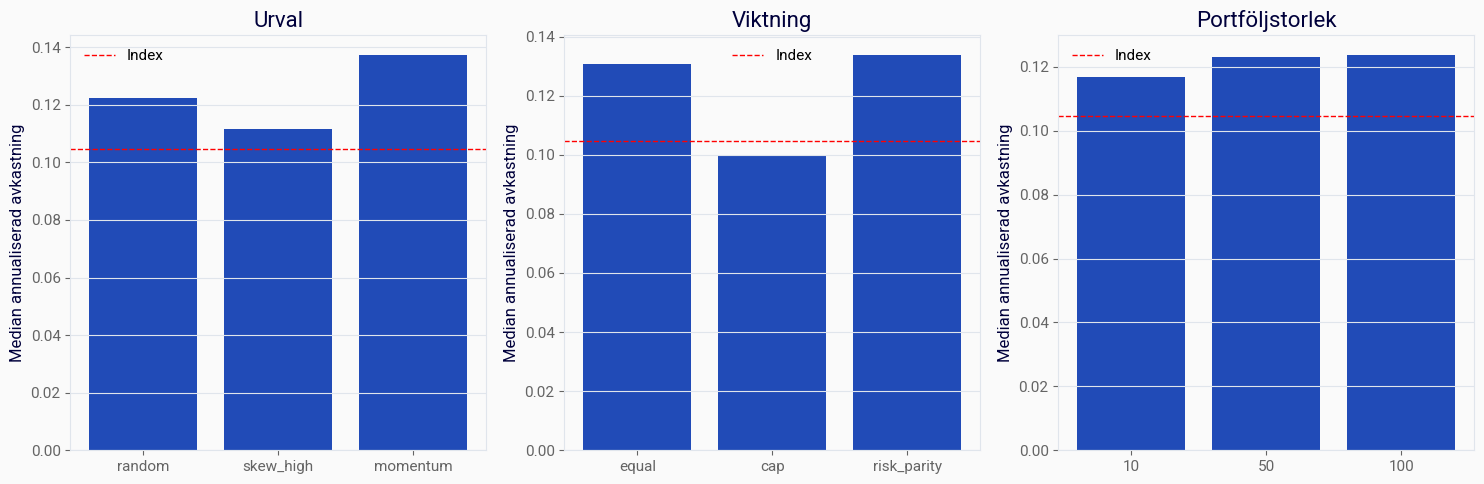

In [33]:
# === Median-avkastning per dimension ===
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metric = 'Return'

dims = [
    ('selection', 'Urval',            MC_SELECTIONS),
    ('weighting', 'Viktning',          MC_WEIGHTINGS),
    ('pf_size',   'Portföljstorlek',   MC_PF_SIZES),
]

for ax, (level, label, order) in zip(axes, dims):
    # Välj ut bara rader för valt metric
    data = mc_result.xs(metric, level='metric')
    # Median per grupp (aggregerar övriga dimensioner), sedan median över körningar
    medians = data.groupby(level=level).median().median(axis=1)
    medians = medians.reindex([str(o) if isinstance(o, int) else o for o in order])
    if medians.isna().all():
        medians = data.groupby(level=level).median().median(axis=1)
    ax.bar(medians.index.astype(str), medians.values)
    ax.axhline(bench_kfs[metric], color='red', linestyle='--', label='Index')
    ax.set_title(label)
    ax.set_ylabel('Median annualiserad avkastning')
    ax.legend()

plt.tight_layout()
plt.show()


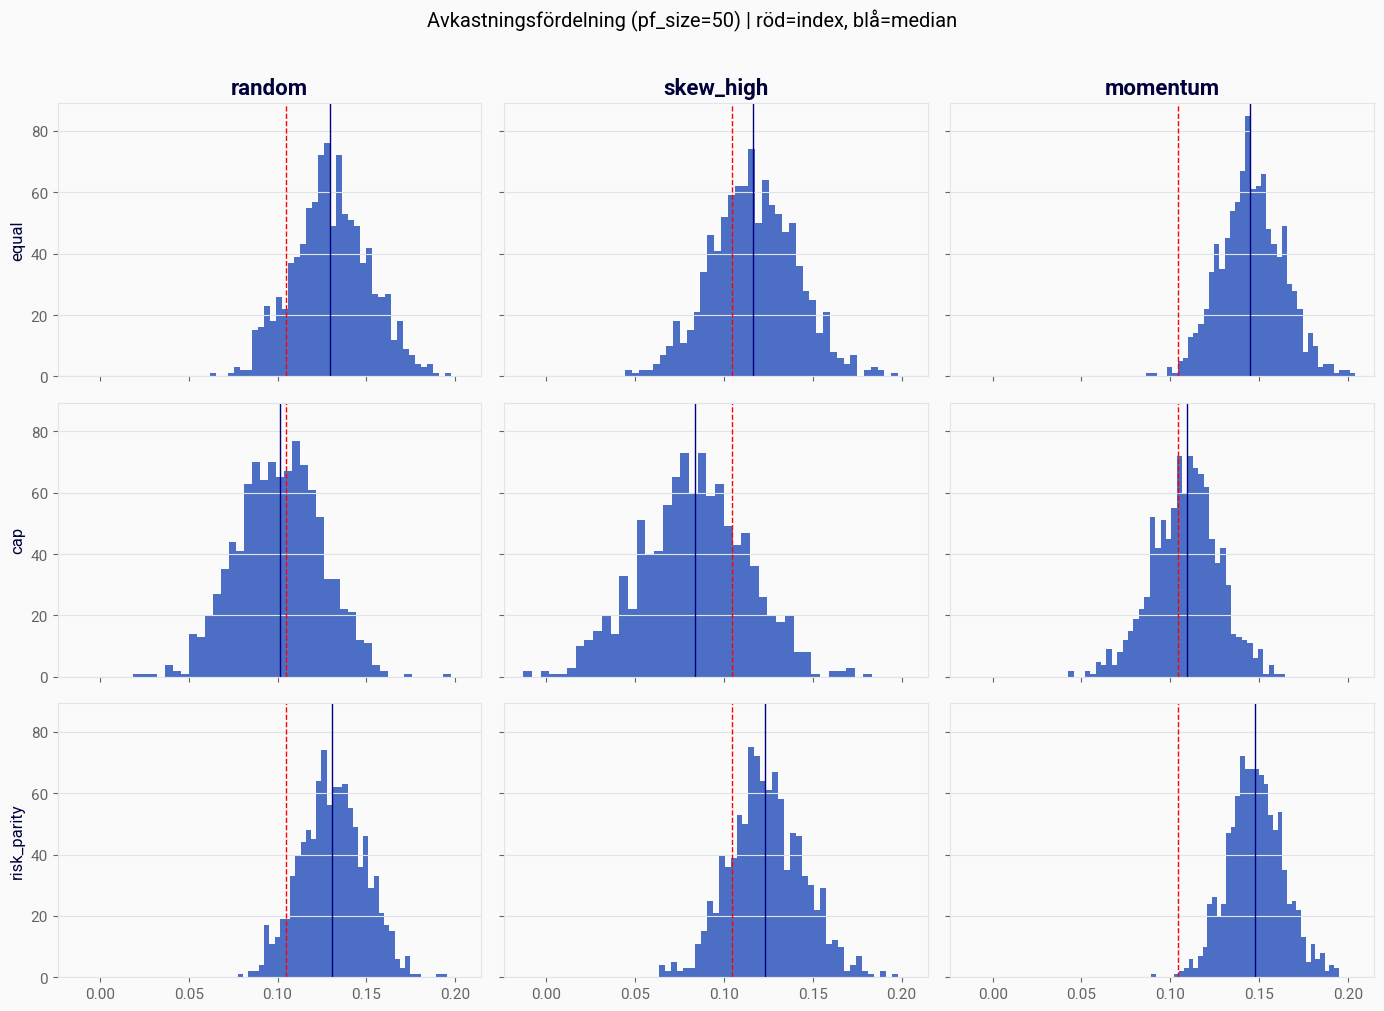

In [34]:
# === Fördelning av avkastning per urval × viktning (pf_size=50) ===
metric   = 'Return'
sz_focus = 50

fig, axes = plt.subplots(
    len(MC_WEIGHTINGS), len(MC_SELECTIONS),
    figsize=(14, 10), sharex=True, sharey=True
)

bench_val = bench_kfs[metric]

for row, wgt in enumerate(MC_WEIGHTINGS):
    for col, sel in enumerate(MC_SELECTIONS):
        ax = axes[row][col]
        try:
            vals = mc_result.xs(
                (sel, wgt, sz_focus, metric),
                level=['selection', 'weighting', 'pf_size', 'metric']
            ).iloc[0].dropna()
        except KeyError:
            ax.set_title(f'{sel}\n(ej tillgänglig)', color='grey')
            continue
        ax.hist(vals, bins=40, edgecolor='none', alpha=0.8)
        ax.axvline(bench_val, color='red', linestyle='--', linewidth=1, label='Index')
        ax.axvline(float(vals.median()), color='navy', linestyle='-', linewidth=1, label='Median')
        if row == 0:
            ax.set_title(sel, fontweight='bold')
        if col == 0:
            ax.set_ylabel(wgt)

fig.suptitle(f'Avkastningsfördelning (pf_size={sz_focus}) | röd=index, blå=median', y=1.01)
plt.tight_layout()
plt.show()


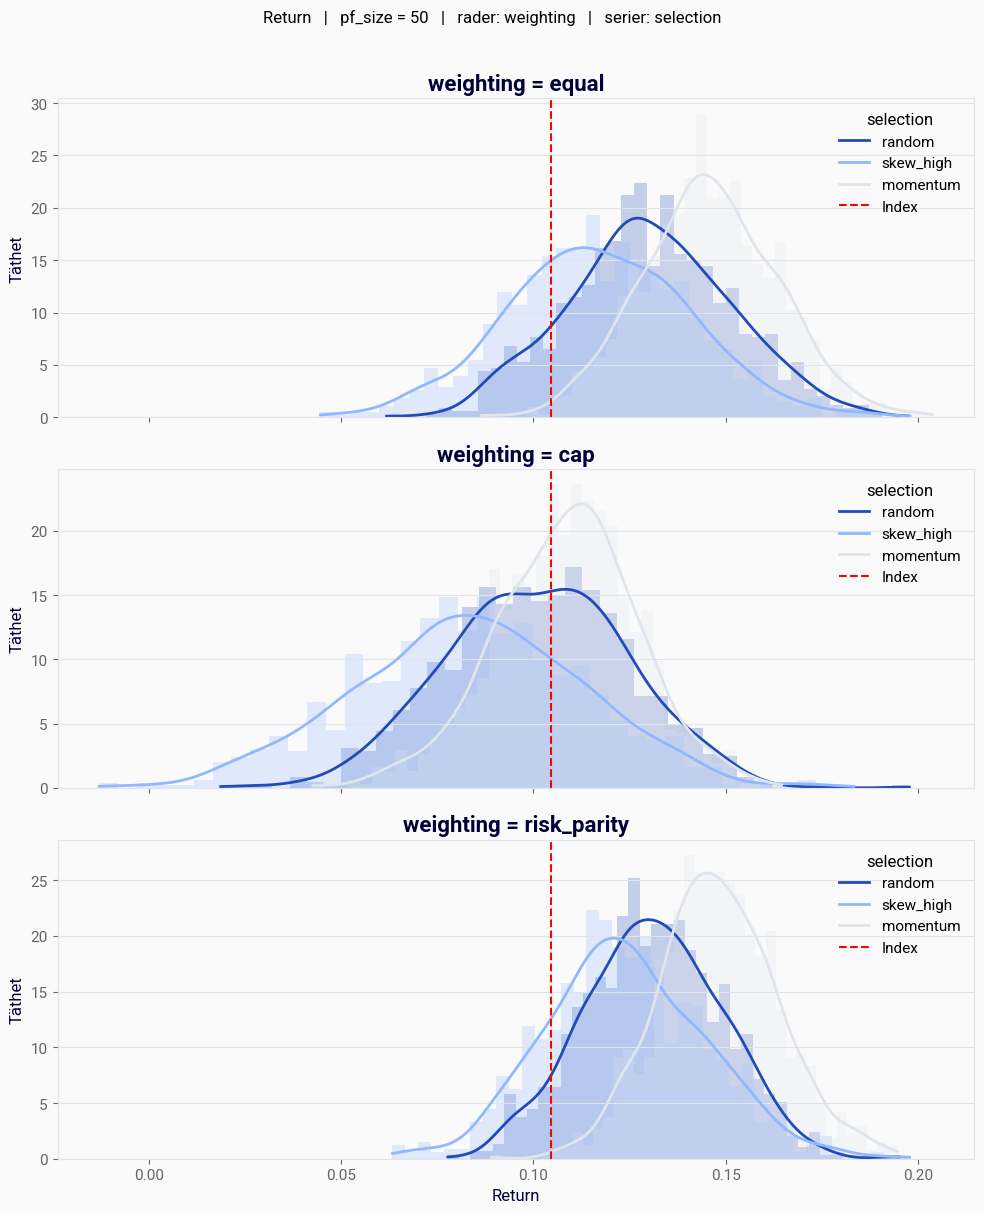

In [39]:
from scipy.stats import gaussian_kde

# ── Inställningar ────────────────────────────────────────────────────────
kf        = 'Return'                      # KFS-mått att plotta
fixed_dim = ('pf_size', 50)              # (dimension, värde) som hålls fast
row_dim   = 'weighting'                   # en rad per värde i denna dimension
chart_dim = 'selection'                     # en serie per värde (olika färger)

# ── Dimensionsvärden ─────────────────────────────────────────────────────
_dim_values = {
    'selection': MC_SELECTIONS,
    'weighting': MC_WEIGHTINGS,
    'pf_size':   MC_PF_SIZES,
}
row_values   = _dim_values[row_dim]
chart_values = _dim_values[chart_dim]
fixed_level, fixed_val = fixed_dim

# Nivåordning i mc_result – används för att bygga loc-nyckel
_level_order = list(mc_result.index.names)  # ['selection','weighting','pf_size','metric']

def _get_vals(row_val, chart_val):
    """Hämta körningsfördelningen för en (row, chart)-kombination."""
    selector = {
        row_dim:     row_val,
        chart_dim:   chart_val,
        fixed_level: fixed_val,
        'metric':    kf,
    }
    key = tuple(selector[lvl] for lvl in _level_order)
    try:
        vals = mc_result.loc[key]
        if isinstance(vals, pd.DataFrame):
            vals = vals.squeeze()
        return vals.dropna().astype(float)
    except KeyError:
        return pd.Series(dtype=float)

# ── Plot ─────────────────────────────────────────────────────────────────
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

fig, axes = plt.subplots(
    len(row_values), 1,
    figsize=(10, 4 * len(row_values)),
    sharex=True
)
if len(row_values) == 1:
    axes = [axes]

for ax, row_val in zip(axes, row_values):
    for ci, chart_val in enumerate(chart_values):
        vals = _get_vals(row_val, chart_val)
        if len(vals) < 2:
            continue

        color = colors[ci % len(colors)]
        label = str(chart_val)

        ax.hist(vals, bins=40, alpha=0.25, color=color, density=True)
        kde = gaussian_kde(vals)
        x   = np.linspace(vals.min(), vals.max(), 300)
        ax.plot(x, kde(x), color=color, linewidth=2, label=label)

    ax.axvline(bench_kfs[kf], color='red', linestyle='--',
               linewidth=1.5, label='Index')
    ax.set_title(f'{row_dim} = {row_val}', fontweight='bold')
    ax.set_ylabel('Täthet')
    ax.legend(title=chart_dim, framealpha=0.7)

axes[-1].set_xlabel(kf)
fig.suptitle(
    f'{kf}   |   {fixed_level} = {fixed_val}   |   '
    f'rader: {row_dim}   |   serier: {chart_dim}',
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.show()
